In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/creator_feature_engineered.csv"
)

print(df.shape)
df.head()

(23144, 44)


,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,virality_score,save_rate,comment_rate,like_rate,share_rate,cta_engagement,creator_tier,performance_score,content_efficiency,performance_category
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,0.161775,0.785764,0.115554,4.483476,0.161775,240,Nano,36.744630,3.852327,High
1,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,0.061013,1.342282,0.122026,6.955461,0.061013,0,Nano,6.316368,5.313456,Low
2,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0.243309,0.000000,0.000000,3.163017,0.243309,0,Nano,9.580035,3.090508,Low
3,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,0.093458,0.392523,0.149533,2.878505,0.093458,0,Micro,10.136725,2.210984,Medium
4,IG0000006,7,brand,3551,carousel,Photography,Reels Feed,1,2025-05-06 08:00:00,2025-05-06,...,0.149925,0.862069,0.112444,5.584708,0.149925,179,Nano,22.748176,5.155530,Medium


In [12]:
df.isnull().sum()

post_id                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
is_weekend                  0
year                        0
month                       0
month_name                  0
quarter                     0
week                        0
time_slot                   0
total_engagement            0
engagement_per_follower     0
reach_rate                  0
impression

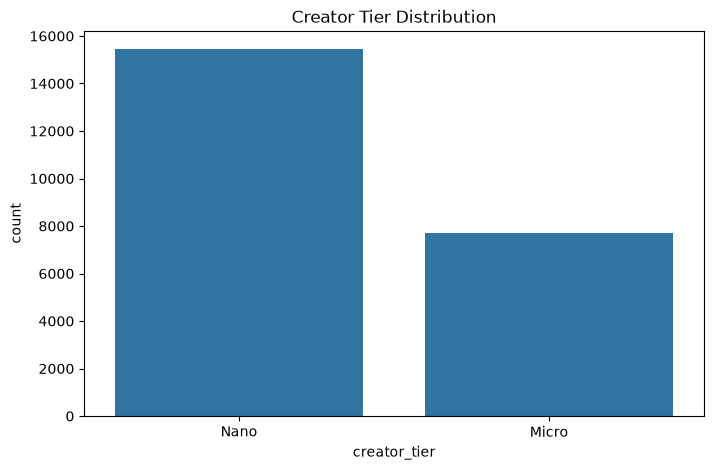

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="creator_tier"
)

plt.title("Creator Tier Distribution")

plt.savefig(
    "../visuals/creator_type_performance.png",
    bbox_inches="tight"
)

plt.show()

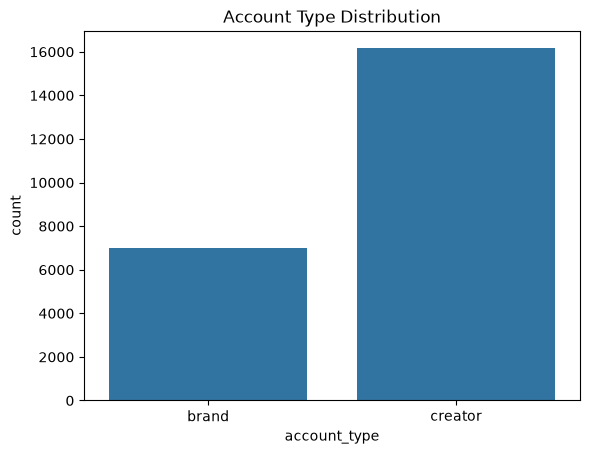

In [31]:
sns.countplot(
    data=df,
    x="account_type"
)

plt.title("Account Type Distribution")

plt.savefig(
    "../visuals/account_type_distribution.png",
    bbox_inches="tight"
)
plt.show()

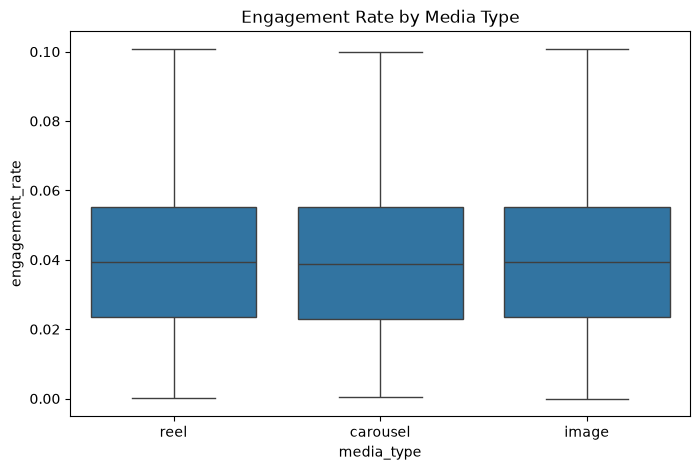

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="media_type",
    y="engagement_rate"
)

plt.title("Engagement Rate by Media Type")

plt.show()

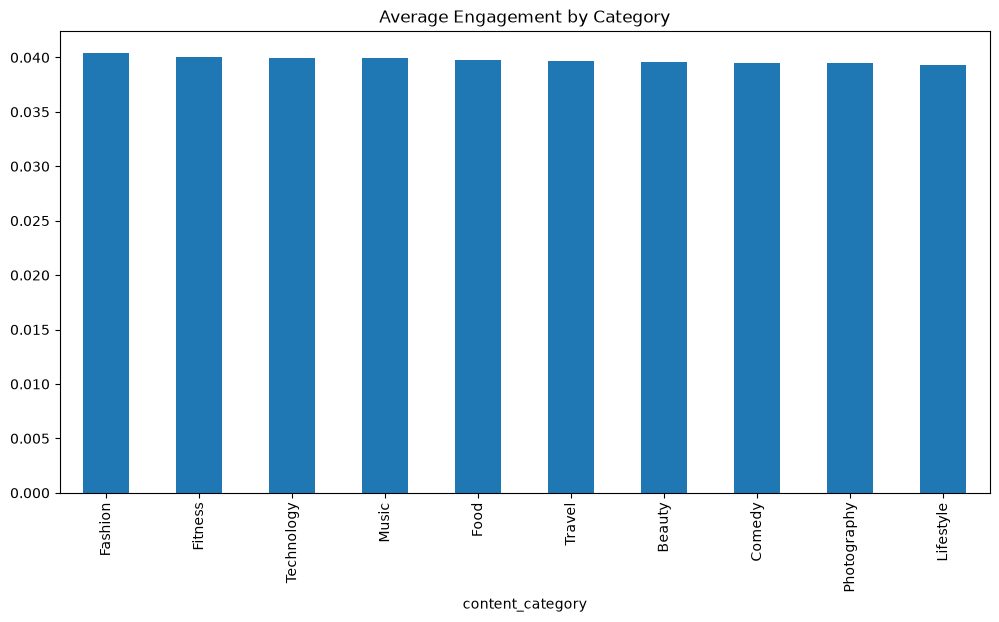

In [32]:
category_eng = (
    df.groupby("content_category")
    ["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

category_eng.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Engagement by Category")
plt.savefig(
    "../visuals/content_category_performance.png",
    bbox_inches="tight"

)
plt.show()

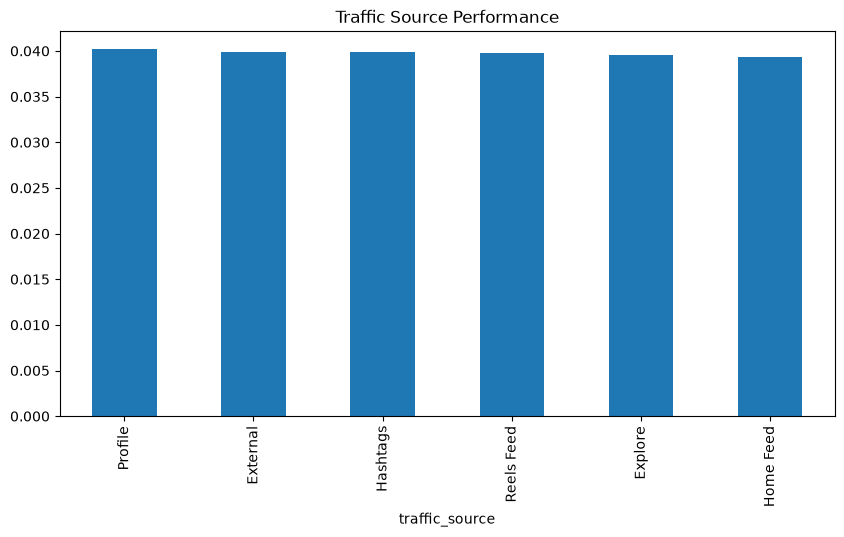

In [17]:
traffic_eng = (
    df.groupby("traffic_source")
    ["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

traffic_eng.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Traffic Source Performance")

plt.show()

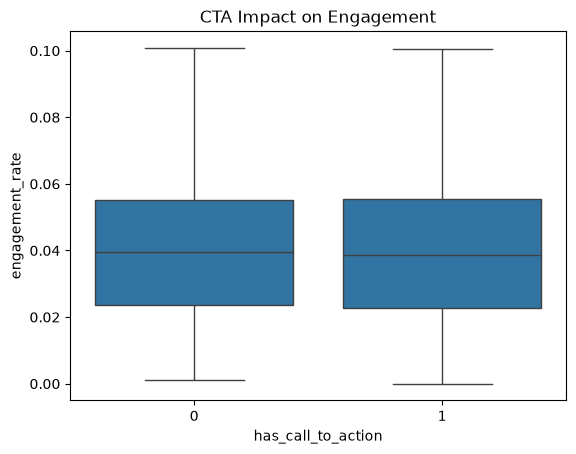

In [33]:
sns.boxplot(
    data=df,
    x="has_call_to_action",
    y="engagement_rate"
)

plt.title("CTA Impact on Engagement")

plt.savefig(
    "../visuals/cta_impact_on_engagement.png",
    bbox_inches="tight"
)
plt.show()

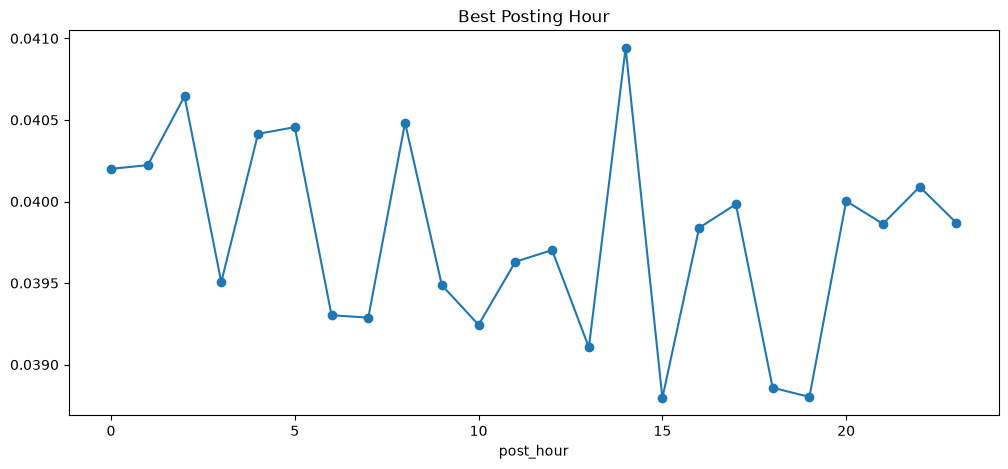

In [34]:
hourly_eng = (
    df.groupby("post_hour")
    ["engagement_rate"]
    .mean()
)

hourly_eng.plot(
    kind="line",
    marker="o",
    figsize=(12,5)
)

plt.title("Best Posting Hour")

plt.savefig(

    "../visuals/post_hour_performance.png",

    bbox_inches="tight"

)

plt.show()

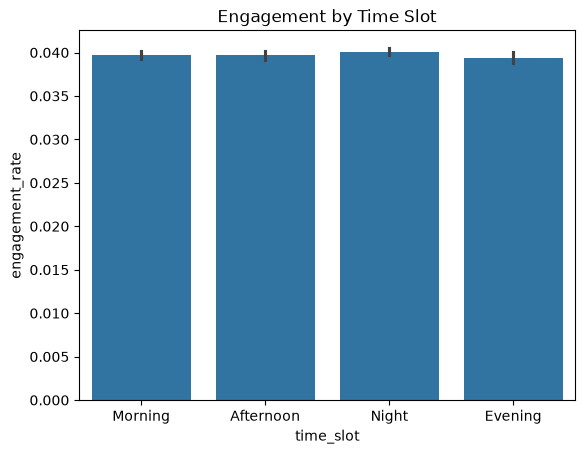

In [35]:
sns.barplot(
    data=df,
    x="time_slot",
    y="engagement_rate"
)

plt.title("Engagement by Time Slot")

plt.savefig(

    "../visuals/time_slot_performance.png",

    bbox_inches="tight"

)

plt.show()

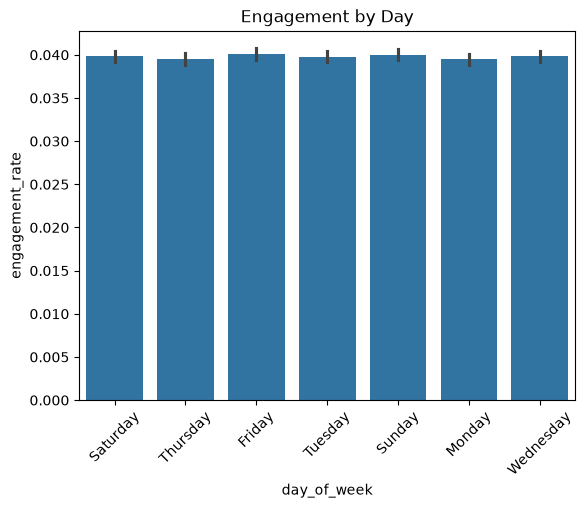

In [36]:
sns.barplot(
    data=df,
    x="day_of_week",
    y="engagement_rate"
)

plt.xticks(rotation=45)

plt.title("Engagement by Day")

plt.savefig(
    "../visuals/day_of_week_performance.png",
    bbox_inches="tight"
)
plt.show()

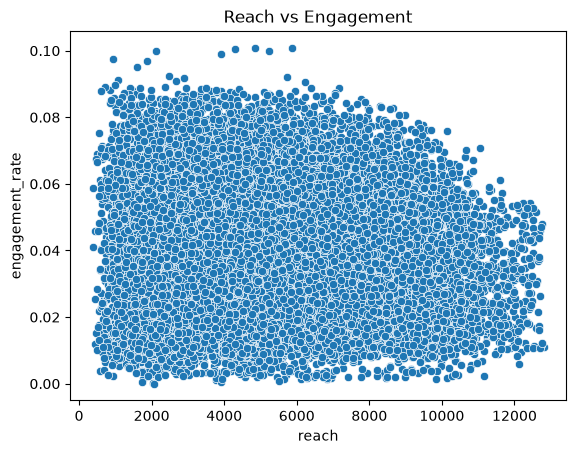

In [37]:
sns.scatterplot(
    data=df,
    x="reach",
    y="engagement_rate"
)

plt.title("Reach vs Engagement")

plt.savefig(
    "../visuals/reach_vs_engagement_performance.png",
    bbox_inches="tight"
)
plt.show()

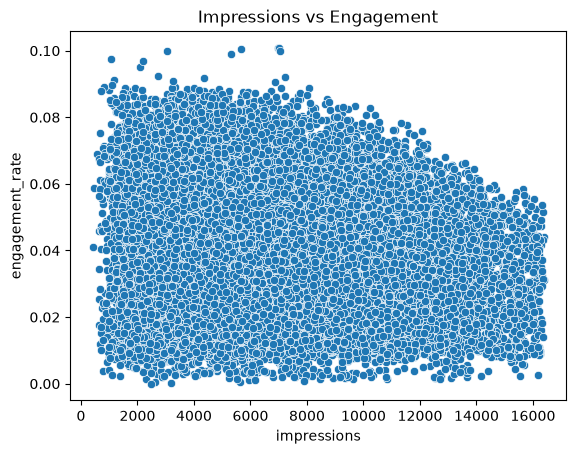

In [38]:
sns.scatterplot(
    data=df,
    x="impressions",
    y="engagement_rate"
)

plt.title("Impressions vs Engagement")

plt.savefig(
    "../visuals/impressions_vs_engagement_performance.png",
    bbox_inches="tight"
)
plt.show()

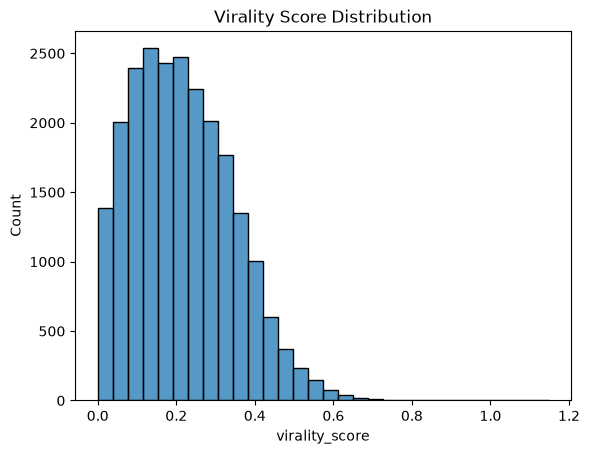

In [39]:
sns.histplot(
    df["virality_score"],
    bins=30
)

plt.title("Virality Score Distribution")

plt.savefig(
    "../visuals/virality_score_distribution.png",
    bbox_inches="tight"
)
plt.show()

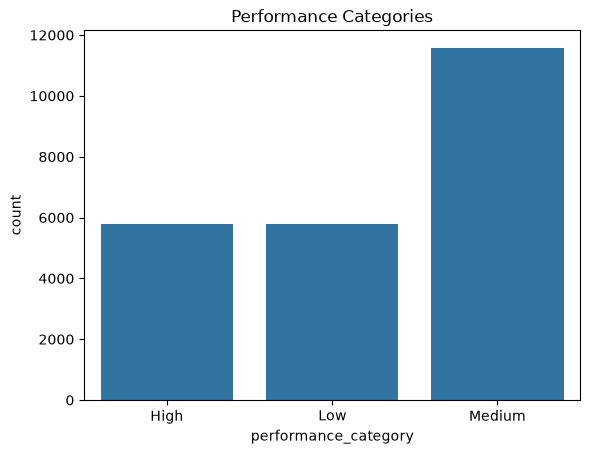

In [40]:
sns.countplot(
    data=df,
    x="performance_category"
)
plt.title("Performance Categories")
plt.savefig(
    "../visuals/performance_categories_performance.png",
    bbox_inches="tight"
)
plt.show()

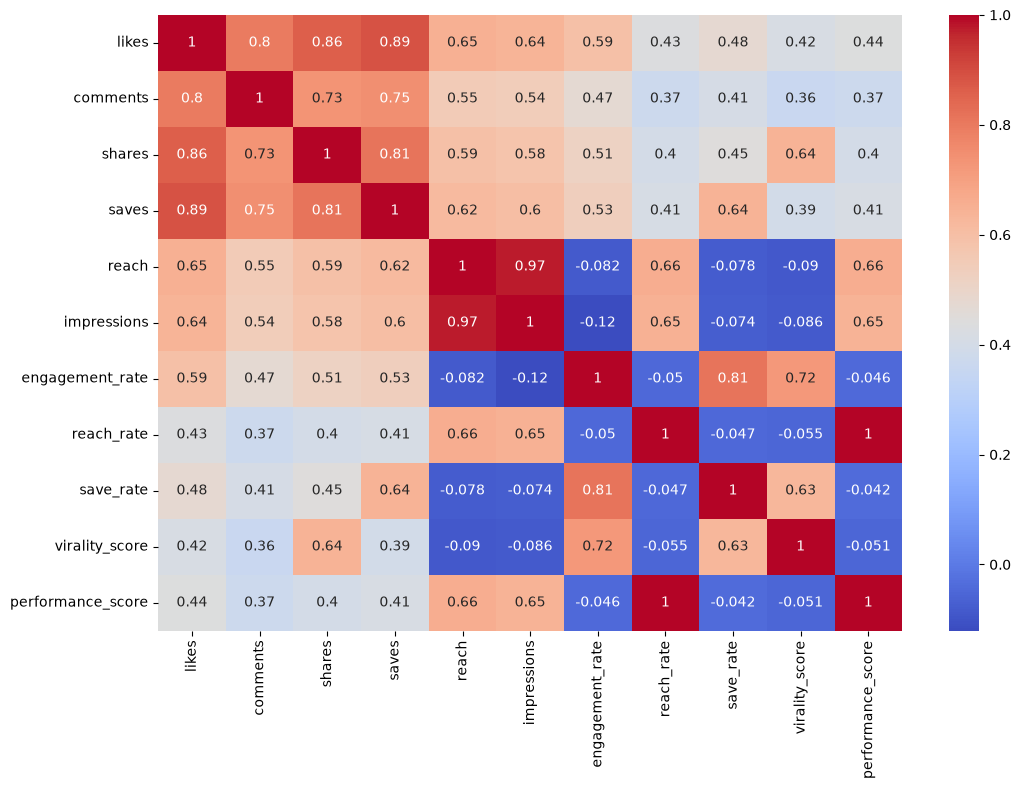

In [41]:
plt.figure(figsize=(12,8))

corr_cols = [
    "likes",
    "comments",
    "shares",
    "saves",
    "reach",
    "impressions",
    "engagement_rate",
    "reach_rate",
    "save_rate",
    "virality_score",
    "performance_score"
]

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.savefig(
    "../visuals/heatmap.png",
    bbox_inches="tight"
)
plt.show()

In [27]:
top_posts = df.nlargest(
    20,
    "performance_score"
)

top_posts[
[
    "account_id",
    "content_category",
    "media_type",
    "performance_score"
]
]

,account_id,content_category,media_type,performance_score
4753,14,Travel,image,122.510530
8414,14,Technology,carousel,121.911197
20171,14,Technology,carousel,120.422725
11502,14,Beauty,carousel,118.488909
21731,14,Food,carousel,117.675723
4981,14,Fashion,carousel,117.512574
21704,14,Technology,carousel,116.842923
1891,14,Food,reel,116.418377
10222,14,Food,carousel,116.388423
14041,14,Fashion,carousel,116.118691


In [29]:
plt.savefig(
    "../visuals/media_type_performance.png"
)

<Figure size 640x480 with 0 Axes>